# **1) MinMaxScaling**

weight
120
60
76
45
76
28
.
.
.
.
.
n=100

minmaxscaling formula: **X'i = (Xi-Xmin)/(Xmax-Xmin)** *Belongs to [0,1]*

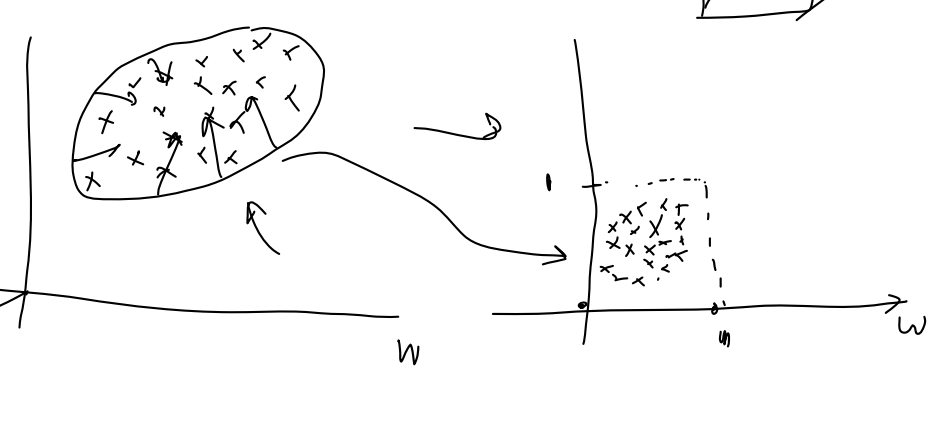

In [90]:
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv('wine_data.csv', header=None, usecols=[0,1,2])

In [9]:
df.columns=['Class Label', 'Alcohol', 'Malic Acid']

In [10]:
df

,Class Label,Alcohol,Malic Acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59
...,...,...,...
173,3,13.71,5.65
174,3,13.40,3.91
175,3,13.27,4.28
176,3,13.17,2.59


<Axes: xlabel='Alcohol', ylabel='Density'>

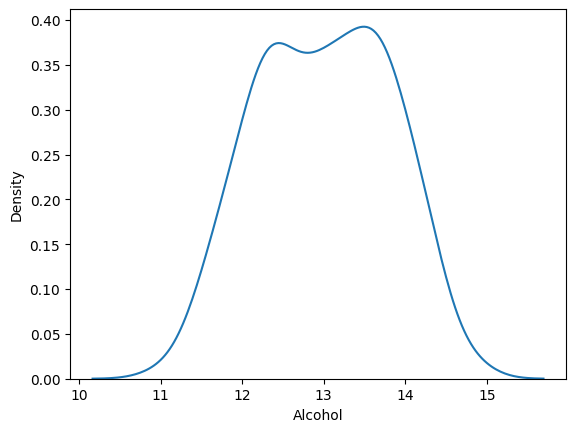

In [13]:
sns.kdeplot(df['Alcohol'])

<Axes: xlabel='Malic Acid', ylabel='Density'>

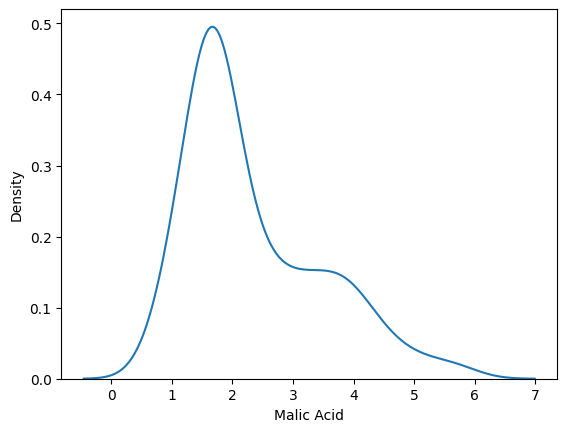

In [15]:
sns.kdeplot(df['Malic Acid'])

<Axes: xlabel='Alcohol', ylabel='Malic Acid'>

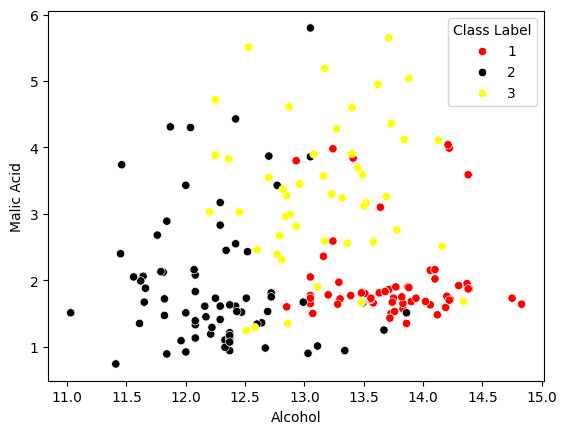

In [26]:
sns.scatterplot(x=df['Alcohol'], y=df['Malic Acid'], hue=df['Class Label'], palette=['red','black','yellow'])

## MinmMaxScaling

In [44]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(df.drop('Class Label', axis=1),
                                                df['Class Label'],
                                                test_size=0.3,
                                                random_state=0)

x_train.shape, x_test.shape

((124, 2), (54, 2))

In [71]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaler.fit(x_train) #we only fit train data

x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [72]:
x_train_scaled #sklearn converted pd df to np array so we have to convert it back to pd df

array([[0.72043011, 0.20378151],
       [0.31989247, 0.08403361],
       [0.60215054, 0.71218487],
       [0.57258065, 0.56302521],
       [0.76075269, 0.1302521 ],
       [0.48924731, 0.5       ],
       [0.75537634, 0.67857143],
       [0.61021505, 0.17436975],
       [0.54301075, 0.62394958],
       [0.39784946, 0.07352941],
       [0.33870968, 0.1092437 ],
       [0.46774194, 0.53361345],
       [0.5188172 , 0.53781513],
       [0.70967742, 0.07563025],
       [0.57258065, 0.30882353],
       [0.36021505, 0.0105042 ],
       [0.38709677, 0.13235294],
       [0.20967742, 0.25840336],
       [0.59408602, 0.64915966],
       [0.82526882, 0.26680672],
       [0.15591398, 0.09663866],
       [0.52688172, 0.16386555],
       [0.46774194, 0.31512605],
       [0.65860215, 0.16386555],
       [0.1155914 , 0.5987395 ],
       [0.27956989, 0.26680672],
       [0.21236559, 0.12184874],
       [0.65053763, 0.59033613],
       [0.31451613, 0.44957983],
       [0.54301075, 0.17647059],
       [0.

In [75]:
x_train_scaled = pd.DataFrame(x_train_scaled, columns=x_train.columns)
x_test_scaled = pd.DataFrame(x_test_scaled, columns=x_test.columns)

In [84]:
np.round(x_train.describe(),1)

,Alcohol,Malic Acid
count,124.0,124.0
mean,13.0,2.4
std,0.8,1.1
min,11.0,0.9
25%,12.4,1.6
50%,13.0,1.9
75%,13.6,3.2
max,14.8,5.6


In [85]:
np.round(x_train_scaled.describe(),1)

,Alcohol,Malic Acid
count,124.0,124.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.2
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


### *min became 0 and max became 1!*

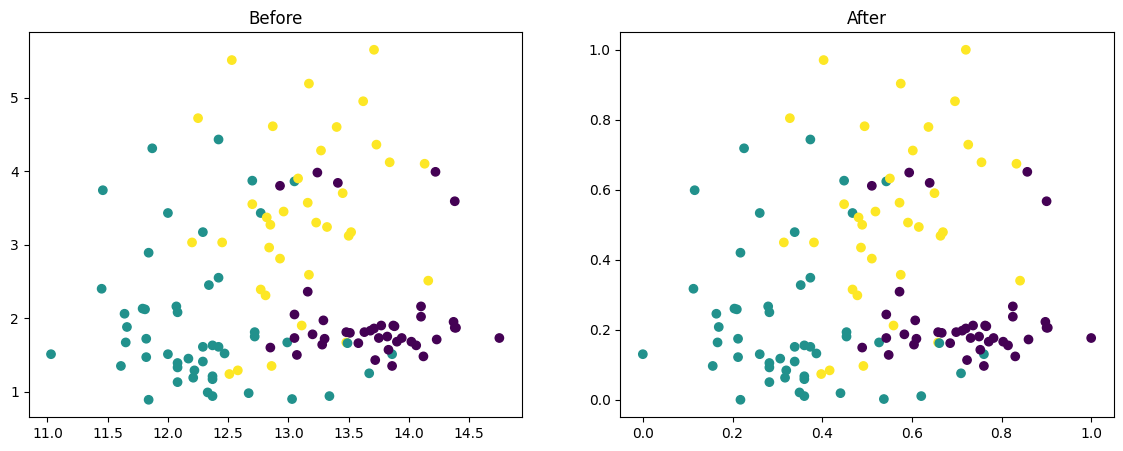

In [100]:
fig, (ax1,ax2) = plt.subplots(ncols=2, figsize=(14,5))

ax1.set_title('Before')
ax1.scatter(x_train['Alcohol'],x_train['Malic Acid'], c=y_train)


ax2.set_title('After')
ax2.scatter(x_train_scaled['Alcohol'], x_train_scaled['Malic Acid'], c=y_train)

### lets plot kdeplot(probability distribution)

<Axes: title={'center': 'After'}, xlabel='Alcohol', ylabel='Density'>

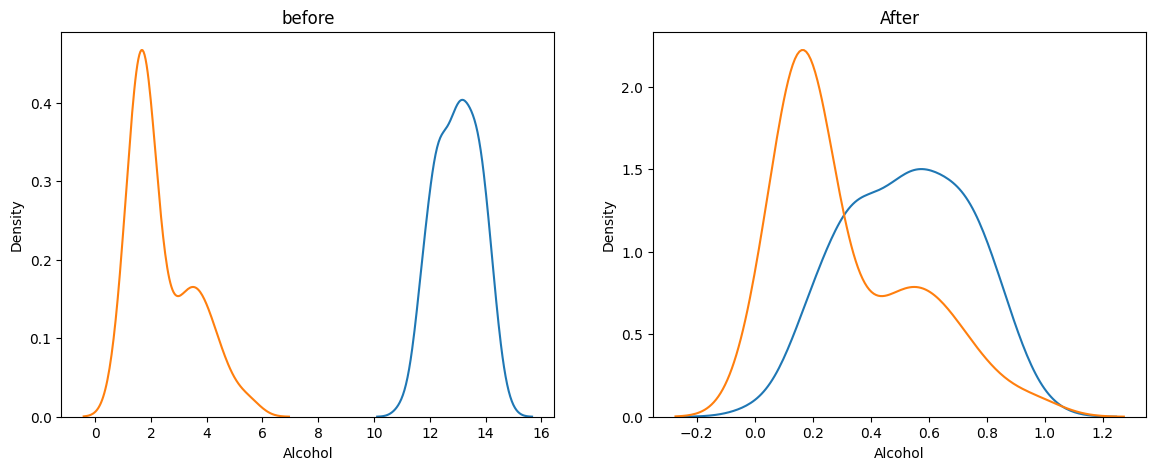

In [111]:
fig, (ax1,ax2) = plt.subplots(ncols=2, figsize=(14,5))

ax1.set_title('before')
sns.kdeplot(x_train['Alcohol'], ax=ax1)
sns.kdeplot(x_train['Malic Acid'], ax=ax1)

ax2.set_title('After')
sns.kdeplot(x_train_scaled['Alcohol'])
sns.kdeplot(x_train_scaled['Malic Acid'])

<Axes: title={'center': 'After'}, xlabel='Alcohol', ylabel='Density'>

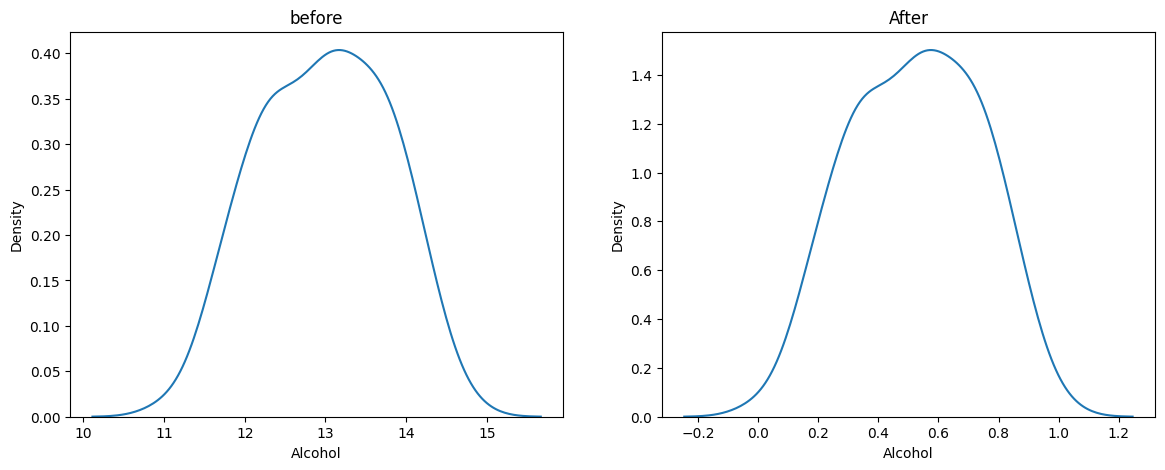

In [114]:
fig, (ax1,ax2) = plt.subplots(ncols=2, figsize=(14,5))

ax1.set_title('before')
sns.kdeplot(x_train['Alcohol'], ax=ax1)

ax2.set_title('After')
sns.kdeplot(x_train_scaled['Alcohol'], ax=ax2)

### **The shape is mantained**

# **2) Mean Nomalisation**

**X'i = (Xi-Xmean)/(Xmax-Xmin)** values belong to [-1,1]

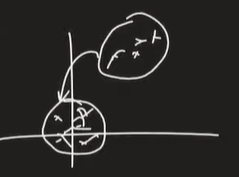

usefull in algos when u want centered data and there is no direct feature availabe for this in sklearn

# **3) MaxAbsScaling**

X'i = Xi/|Xmax|

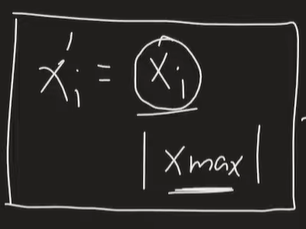

Class used: MaxAbsScaler

usefull for sparse data(too many zeros!)

# **4) RobustScaling**

X'i = (Xi-Xmedian)/IQR

IQR(Inter Quartile Range): 25th %ile - 75th %ile

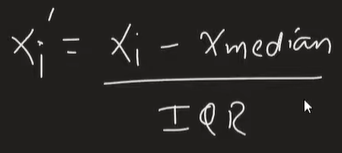

Class: sklearn.preprocessing > RobustScaler

usefull: for data with outlyers


# **Normalisation vs scaleralization**

1) is feature scaling required? (u have to know ml also's internal working to decide if u even need it)
2) if u have to do scaling: (practical tip: most of the problems are solved using Standerdisation)
3) normalisation:
        MinMAx:when u know min and max values(ex: img processing: cnn(0,225))
        Standard scaling: when u have no idea
        RobustScaling: when there are outlyers
        MaxAbsScaling: when u have sparce matrix